# Customer Churn Analysis - Telco 
**Tools:** Python (Pandas, Scikit-learn, Matplotlib) | **Model:** Logistic Regression 

## Business Context
Customer churn is one of the most costly problems a subscription business faces. Acquiring a new customer cost 5-7x more than retaining an existing one. This analysis identifies the key drivers of churn in a telecom dataset and produces a risk-scored customer list that the marketing team can act on immediately. 

**Core questions this analysis answers:**
- What is the overall churn rate and what does it cost the business ?
- Which customer segments are most at risk of churning ?
- What factors drive churn - and which can marketing influence ? 
- Which specific customers should retention campaigns target first ? 

In [4]:
# imports 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [ ]:
# load data
df = pd.read_csv('data/WA_Fn-UseC_-Telco-Customer-Churn.xls')

## Data Overview
- **Source:** IBM Sample Dataset - Telco Customer Churn 
- **Size:** 7,043 customers, 21 features 
- **Target variable:** Churn (yes/no)
- **Key features:** Contract type, tenure, monthly charges, internet services, support add-ons, payment method

Customer with tenure = 0 and TotalCharges = 0 are excluded - these are pre-billing signups who have not completed a full billing cycle and cannot be meaningfully classified as churned or retained. 

In [6]:
# basic overview 
print("dataset shape:", df.shape)
print("\nchurn distribution:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).mul(100).round(1))
print("\nmissing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

dataset shape: (7043, 21)

churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     73.5
Yes    26.5
Name: proportion, dtype: float64

missing values:
Series([], dtype: int64)


## Data Cleaning

In [7]:
# missing value check 
missing = pd.DataFrame({
    "type" : df.dtypes,
    "null_count" : df.isnull().sum(),
    "empty_str_count" : (df == '').sum() + (df == ' ').sum()
})

In [8]:
# check numeric colummns for weird values 
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    print(f"\n--{col}--")
    print(f"Min: {df[col].min()} | Max: {df[col].max()} | Unique : {df[col].nunique()}")


--SeniorCitizen--
Min: 0 | Max: 1 | Unique : 2

--tenure--
Min: 0 | Max: 72 | Unique : 73

--MonthlyCharges--
Min: 18.25 | Max: 118.75 | Unique : 1585


In [9]:
# clean data - total charges 
## convert TotalCharges to numeric and drop rows with NaN values
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')
df = df.dropna(subset=['TotalCharges'])

In [10]:
# encode binary variables
yes_no_cols = ["Partner", "Dependents", "PhoneService", "PaperlessBilling"]
df[yes_no_cols] = df[yes_no_cols].replace({"Yes":1, "No":0})

/var/folders/w9/2dlg0tvj3lsfh001p854p1xr0000gn/T/ipykernel_16394/3050525941.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[yes_no_cols] = df[yes_no_cols].replace({"Yes":1, "No":0})


In [11]:
# encode target variable 
df["Churn_binary"] = (df["Churn"] == "Yes").astype(int)

## Revenue Impact Calculation

In [12]:
avg_monthly_charges = df[df["Churn"]=='Yes']['MonthlyCharges'].mean()
avg_tenure_lost = df[df["Churn"]=='Yes']['tenure'].mean()
total_churned = df[df["Churn"]=='Yes'].shape[0]

rev_lost_per_cust = avg_monthly_charges * avg_tenure_lost
total_revenue_lost = rev_lost_per_cust * total_churned

print(f'Total Churned Customers:{total_churned}')
print(f'Average monthly charge at churn: ${avg_monthly_charges:.2f}')
print(f'Average tenure before churn: {avg_tenure_lost:.1f} months')
print(f'Average revenue lost per churned customer: ${rev_lost_per_cust:.2f}')
print(f'Total estimated revenue lost due to churn: ${total_revenue_lost:.2f}')

Total Churned Customers:1869
Average monthly charge at churn: $74.44
Average tenure before churn: 18.0 months
Average revenue lost per churned customer: $1338.39
Total estimated revenue lost due to churn: $2501452.09


## Exploratory Analysis 
Before modelling, we examine the relationship between churn and the variables most relevant to marketing - contract type, customer tenure, pricing and service adoption. Each finding directly informs a campaign recommendation. 

### Churn by Contract Type
Contract type is the most actionable churn signal for marketing because it is directly influenced by retention campaigns. Customers on month-to-month contracts have no commitment and can leave at any billing cycle. 

In [13]:
# churn rate by contract type - calculate churn rate
contract_churn = df.groupby("Contract")["Churn_binary"].mean().reset_index()
contract_churn.columns = ["Contract", "Churn_Rate"]
contract_churn["churn_rate%"] = (contract_churn["Churn_Rate"] * 100).round(2)

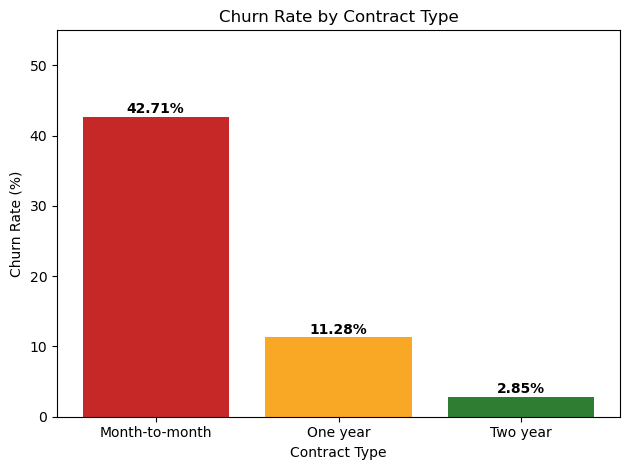

In [14]:
# churn rate by contract type - barplot 
fig, ax = plt.subplots()
bars = ax.bar(contract_churn["Contract"], contract_churn["churn_rate%"], color=['#C62828', '#F9A825', '#2E7D32'])
ax.set_title("Churn Rate by Contract Type")
ax.set_xlabel("Contract Type")
ax.set_ylabel("Churn Rate (%)")
ax.set_ylim(0,55)

# adding values to the bars 
for bar, val in zip(bars, contract_churn["churn_rate%"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
            f"{val}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

### Churn by Tenure
Tenure reveals *when* in the customer lifecycle churn is most likely. Early-stage churn (0-12 months) indicates an onboarding problem. Late stage churn indicates a value or pricing problem. The intervention strategy differs significantly depending on which pattern dominates. 

In [15]:
# create a tenure bucket 
df['tenure_group'] = pd.cut(df['tenure'], 
                            bins=[0, 12, 24, 36, 48, 60, 72], 
                            labels=['0-12', '13-24', '25-36', '37-48', '49-60', '61-72'])

tenure_churn = df.groupby('tenure_group', observed = True)['Churn_binary'].mean().reset_index()
tenure_churn['churn_rate%'] = (tenure_churn['Churn_binary'] * 100).round(2)

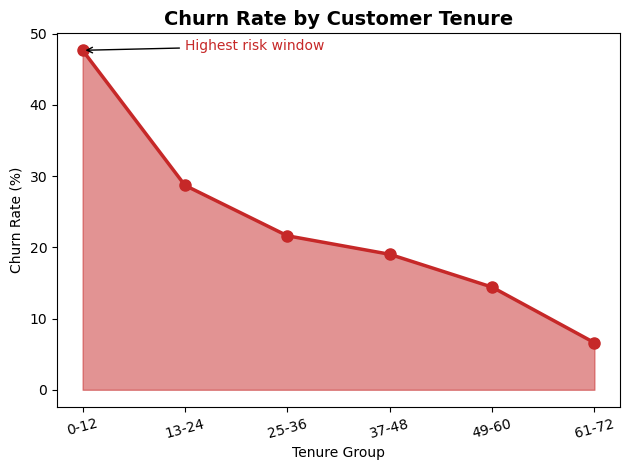

In [16]:
# churn by tenure plot 
fig, ax = plt.subplots()
ax.plot(tenure_churn['tenure_group'], tenure_churn['churn_rate%'], 
        marker = "o", linewidth = 2.5, color = "#C62828", markersize = 8)

ax.fill_between(range(len(tenure_churn)), tenure_churn['churn_rate%'], 
                alpha = 0.5, color = "#C62828")

ax.set_title("Churn Rate by Customer Tenure", fontsize = 14, fontweight = "bold")
ax.set_xlabel("Tenure Group")
ax.set_ylabel("Churn Rate (%)")
ax.set_xticks(range(len(tenure_churn)))
ax.set_xticklabels(tenure_churn['tenure_group'], rotation = 15)

# annotate the highest risk period 
ax.annotate("Highest risk window", 
            xy = (0, tenure_churn['churn_rate%'].iloc[0]), 
            xytext=(1, tenure_churn['churn_rate%'].iloc[0]), 
            arrowprops=dict(arrowstyle = "->", color = 'black'), 
            fontsize = 10, color = "#C62828")

plt.tight_layout()
plt.show()

### Churn by Monthly Charges 
If churned customers consistently pay more than retained customers, this signals pricing sensitivity - customers are questioning whether the service is worth the cost. This finding would support targeted retention offers for high-paying customers. 

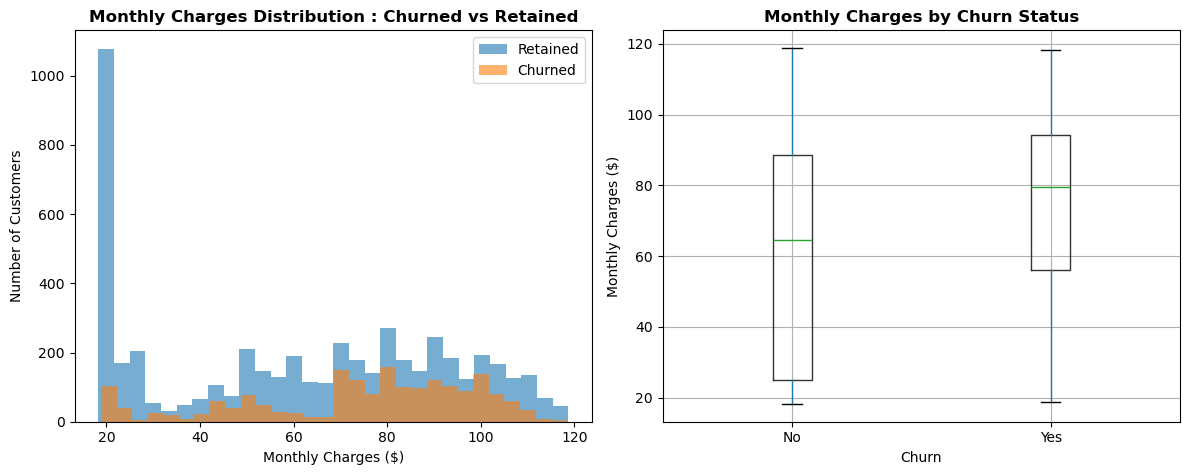

In [17]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))

# histogram - distribution of monthly charges by churn 
churned = df[df["Churn_binary"] == 1]['MonthlyCharges']
retained = df[df["Churn_binary"] == 0]['MonthlyCharges']

axes[0].hist(retained, bins=30, alpha = 0.6, label = "Retained")
axes[0].hist(churned, bins=30, alpha=0.6, label='Churned')
axes[0].set_title('Monthly Charges Distribution : Churned vs Retained', 
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Number of Customers')
axes[0].legend()

# boxplot 
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1], boxprops=dict(color='#333333'))
axes[1].set_title('Monthly Charges by Churn Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Monthly Charges ($)')
plt.suptitle('')

plt.tight_layout()
plt.show()

### Churn by Internet and Support Services 
Customers who subscribe to add-on services (TechSupport, OnlineSecurity) have more touchpoints with the product and derive more value from it. Lower churn among these customers suggests that upselling services is a retention strategy, not just a revenue strategy. 

In [18]:
services = ['TechSupport', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection']
churn_rates = []

# calculate churn rate for customers who do not have each service
for service in services : 
    rate = df[df[service] == "No"]['Churn_binary'].mean() * 100 
    churn_rates.append({'Service' : service, 'Churn_Rate' : round(rate, 2)})

# convert to dataframe for visualization
churn_rates_df = pd.DataFrame(churn_rates).sort_values(by='Churn_Rate', ascending=True)

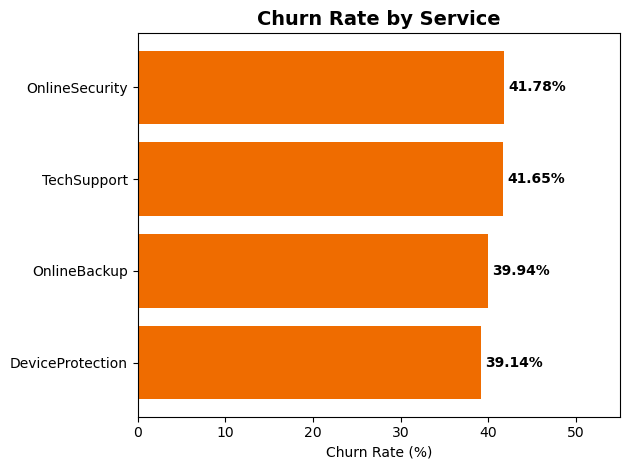

In [19]:
# visualization 
fig, ax = plt.subplots()
bars = ax.barh(churn_rates_df['Service'], churn_rates_df['Churn_Rate'], color = '#EF6C00')
ax.set_title("Churn Rate by Service", fontsize = 14, fontweight = "bold")
ax.set_xlabel('Churn Rate (%)')
ax.set_xlim(0, 55)

# annotate the bars with churn rate values
for bar, val in zip(bars, churn_rates_df['Churn_Rate']):
    ax.text(bar.get_width()+ 0.5, bar.get_y() + bar.get_height()/2, f'{val}%', va='center', fontweight = 'bold')

plt.tight_layout()
plt.show()

## Feature Engineering 

In [20]:
# encode all categorical variables for modelling 
df_model = df.copy()

In [21]:
# multi-category columns - one hot encoding
multicat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

df_model = pd.get_dummies(df_model, columns = multicat_cols, drop_first=True)

# gender encoding 
df_model['gender'] = (df_model['gender'] == 'Male').astype(int)

# drop columns not needed for modelling
df_model.drop(columns=['customerID', 'Churn', 'tenure_group', 'TotalCharges'], inplace=True)

print('Features ready :', df_model.shape)
print(df_model.dtypes)

Features ready : (7032, 30)
gender                                     int64
SeniorCitizen                              int64
Partner                                    int64
Dependents                                 int64
tenure                                     int64
PhoneService                               int64
PaperlessBilling                           int64
MonthlyCharges                           float64
Churn_binary                               int64
MultipleLines_No phone service              bool
MultipleLines_Yes                           bool
InternetService_Fiber optic                 bool
InternetService_No                          bool
OnlineSecurity_No internet service          bool
OnlineSecurity_Yes                          bool
OnlineBackup_No internet service            bool
OnlineBackup_Yes                            bool
DeviceProtection_No internet service        bool
DeviceProtection_Yes                        bool
TechSupport_No internet service          

## Train/Test Split and Scale 

In [22]:
X = df_model.drop(columns=['Churn_binary'])
y = df_model['Churn_binary']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# scaling puts every feature on an equal scale
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set shape: {X_train.shape}')
print(f'Test Set: {X_test.shape[0]} rows')
print(f'Churn rate in training set: {y_train.mean():.1%}')

Training set shape: (5625, 29)
Test Set: 1407 rows
Churn rate in training set: 26.6%


## Model 1 - Logistic Regression

In [23]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(x_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_proba_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('==Logistic Regression==')
print(classification_report(y_test, y_pred_lr, target_names=['Retained', 'Churned']))
print(f'ROC AUC Score: {roc_auc_score(y_test, y_proba_lr):.3f}')

==Logistic Regression==
              precision    recall  f1-score   support

    Retained       0.85      0.89      0.87      1033
     Churned       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407

ROC AUC Score: 0.833


## Model 2 - Random Forest 

In [24]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

print('==Random Forest Classifier==')
print(classification_report(y_test, y_pred_rf, target_names=['Retained', 'Churned']))
print(f'ROC AUC Score: {roc_auc_score(y_test, y_proba_rf):.3f}')

==Random Forest Classifier==
              precision    recall  f1-score   support

    Retained       0.83      0.88      0.85      1033
     Churned       0.60      0.48      0.54       374

    accuracy                           0.78      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407

ROC AUC Score: 0.808


### Model chosen - Logistic regression 
Logistic Regression is chosen for this analysis because: 
- It is designed for binary classification (churned/not churned)
- It outputs calibrated probabilities - essential fro risk scoring customers
- Its coefficients are directly interpretable - each feature's direction and magnitude of impact on churn can be read and explained to non-technical stakeholders

The dataset is split 80/20 for training and testing, with stratification to preserve the churn ratio in both sets. 

## Churn Risk Score

In [25]:
# use the full dataset for prediction and scoring
X_full = df_model.drop(columns=['Churn_binary'])

# use the fitted scaler 
X_full_scaled = scaler.transform(X_full)

# add churn probability score to each customer 
df["ChurnProbability"] = lr.predict_proba(X_full_scaled)[:, 1]

# segment into risk tiers 
df['risk_tier'] = pd.cut(df['ChurnProbability'],
                        bins=[0, 0.4, 0.7, 1], 
                        labels=['Low Risk', 'Medium Risk', 'High Risk'])

# risk summary 
risk_summary = df.groupby('risk_tier', observed=True).agg(
    customer_count = ('customerID', 'count'), 
    avg_monthly_charges = ('MonthlyCharges', 'mean'),
    avg_tenure = ('tenure', 'mean'),
    churn_rate = ('Churn_binary', 'mean')
).reset_index()

In [26]:
# export the full scored customer list
df[['customerID', 'ChurnProbability', 'risk_tier', 'Contract', 'tenure', 'MonthlyCharges']].sort_values('ChurnProbability', ascending=False).to_csv('/Users/yenyee/Documents/customer-churn-analysis/scored_customer_list.csv', index=False)

## ROC Curve Comparison 

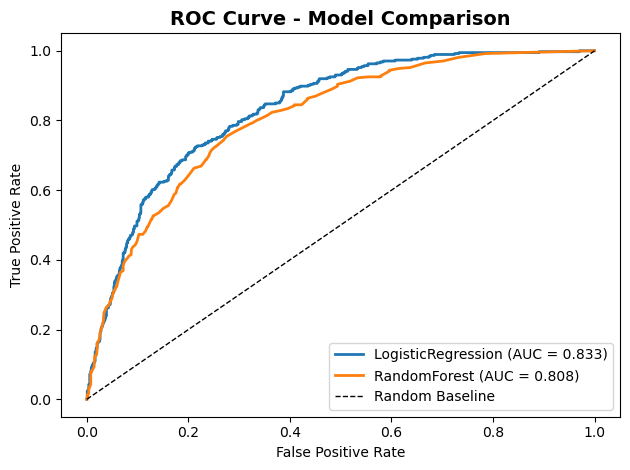

In [27]:
fig, ax = plt.subplots()

for name, prob in [('LogisticRegression', y_proba_lr), ('RandomForest', y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, linewidth = 2, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth = 1, label = 'Random Baseline')
ax.set_title('ROC Curve - Model Comparison', fontsize = 14, fontweight = 'bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate') 
ax.legend()

plt.tight_layout()
plt.show()

## Churn Drivers - Logistic Regression Coefficients 
The coefficient chart shows which features push customer toward churning (red, positive) and which make them more likely to stay (green, negative). This is the msot directly actionable output for marketing - it answers *"what should we fix or promote?"*

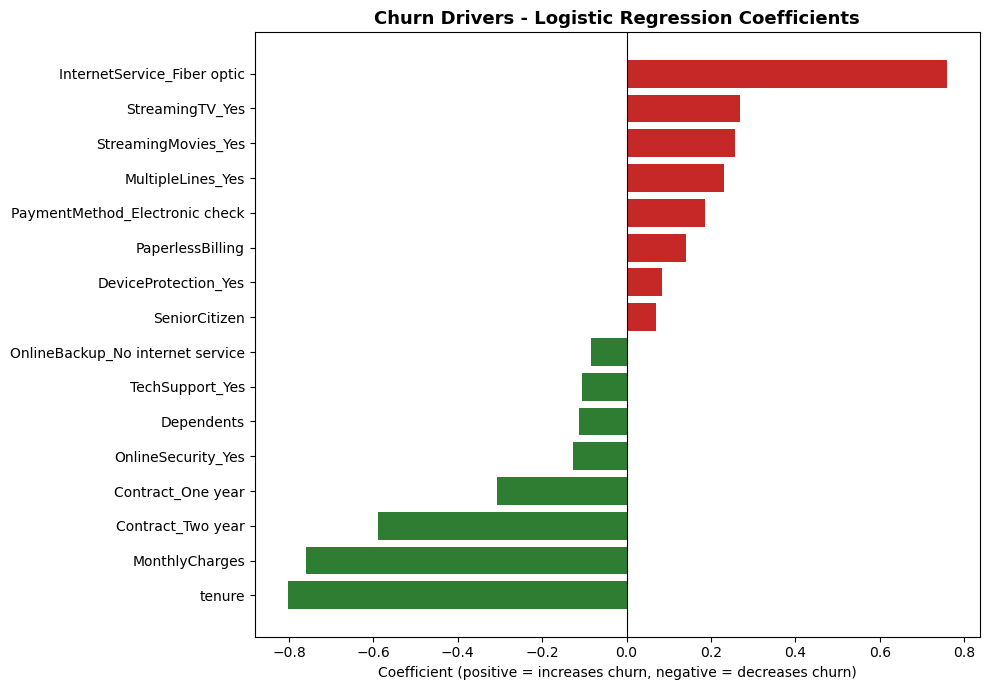

In [28]:
# feature importance - logistic regression coefficients
coef_df = pd.DataFrame({
    'Feature' : X.columns, 
    'Coefficient' : lr.coef_[0]
}).sort_values('Coefficient', ascending = True)

# top drivers in both directions 
top_churn = coef_df.tail(8)
top_retain = coef_df.head(8)
plot_df = pd.concat([top_retain, top_churn])

fig, ax = plt.subplots(figsize = (10, 7))
colors = ['#2E7D32' if c < 0 else '#C62828' for c in plot_df['Coefficient']]
bars = ax.barh(plot_df['Feature'], plot_df['Coefficient'], color = colors)

ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_title('Churn Drivers - Logistic Regression Coefficients', fontsize = 13, fontweight = 'bold')
ax.set_xlabel('Coefficient (positive = increases churn, negative = decreases churn)')

plt.tight_layout()
plt.show()

## Business Recommendations
Based on the churn analysis, four targeted marketing interventions are recommended, ordered by estimated impact. 

---

### 1. Contract Upgrade Campaign 
**Target:** Month-to-month customer in their first 12 months <br>
**Action:** Offer one month free or a locked-in rate discount to upgrade to an annual contract <br>
**Rationale:** Month-to-month customers churn at the highest rate. Locking them into an annual commitment removes the ability to churn impulsively and significantly extends average customer lifetime <br>
**Priority:** High - this is the single highest ROI retention lever

---

### 2. 90-Day Onboarding Retention Programme 
**Target:** All new customers in months 1-3 <br>
**Action:** Structured communication sequence — welcome email on day 1, product tips at day 30, loyalty reward (bill credit or free add-on) at day 90 <br>
**Rationale:** Churn rate is highest in the first 12 months. The onboarding window is the most critical period to build habit and demonstrate value before the customer questions whether to stay <br>
**Priority:** High — prevents churn before it starts 

---

### 3. Support Services Upsell Campaign 
**Target:** Internet customers without TechSupport or OnlineSecurity <br>
**Action:** Targeted email campaign offering a bundled add-on rate for the first 3 months <br>
**Rationale:** Customers without support services churn at nearly double the rate of those with them. Upselling these services reduces churn while also increasing monthly revenue — a dual benefit <br>
**Priority:** Medium — both a retention and revenue play 

---

### 4. High-Value At-Risk Intervention 
**Target:** Customers in the High Risk tier (churn probability > 0.6) paying above average monthly charges on month-to-month contract <br>
**Action:** Proactive outreach — personal call or targeted email — with a retention offer before they initiate cancellation <br>
**Rationale:** Churned customers paid significantly more per month than retained customers, suggesting pricing sensitivity among high-paying customers. Intervening before cancellation is far cheaper than re-acquiring a lost customer <br>
**Priority:** Medium-High — protects highest revenue customers

--- 

### Prioritisation Framework 
The churn risk scores rank every customer by their predicted churn probability. The marketing team should focus retention budget on the **High Risk tier first**, then Medium Risk — applying the relevant campaign based on each customer's contract type and tenure. 

This targeted approach ensures retention spend is concentrated where the revenue at risk is highest, rather than spread across the entire customer base. 